# Customer Segmentation and CLV Prediction

This notebook performs data cleaning and feature engineering for the Online Retail dataset. We aim to prepare the data for customer segmentation (via RFM) and churn/CLV prediction.

In [2]:
import pandas as pd
import numpy as np

# Load full dataset
file_path = "../data/Online Retail.xlsx"  # Update path as needed
df = pd.read_excel(file_path, sheet_name='Online Retail')

# Preview
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with negative Quantity (usually returns)
df = df[df['Quantity'] > 0]

# Remove rows with non-positive UnitPrice
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime (if not already)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Reset index
df = df.reset_index(drop=True)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
# Extract date parts
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['InvoiceWeek'] = df['InvoiceDate'].dt.isocalendar().week
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Check unique customers
unique_customers = df['CustomerID'].nunique()
print(f"Unique customers: {unique_customers}")


Unique customers: 4338


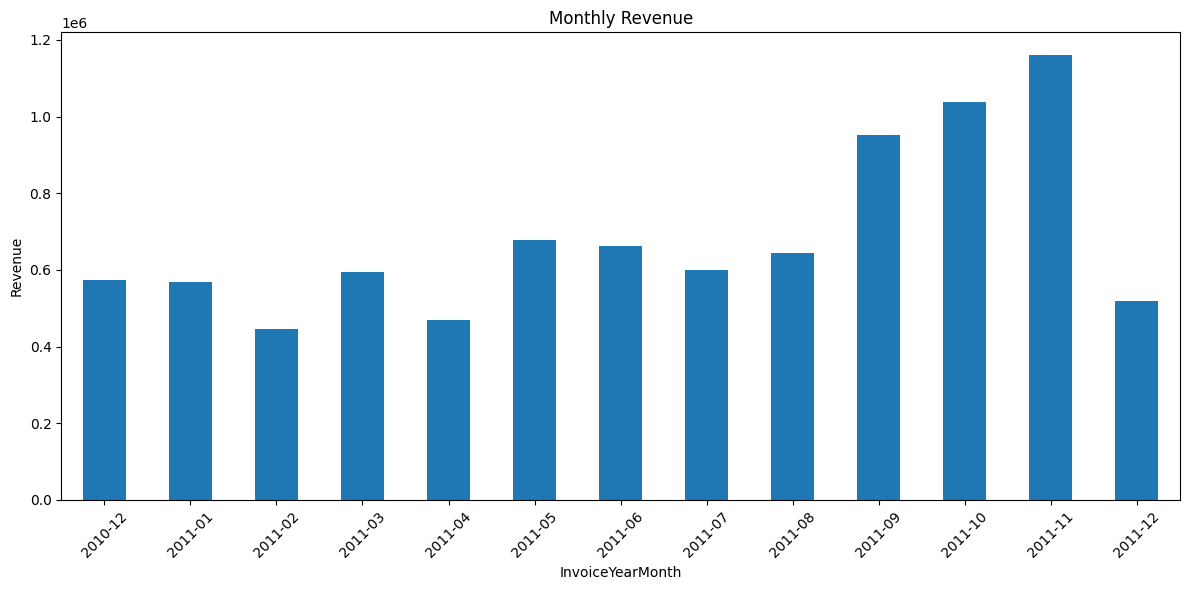

In [5]:
import matplotlib.pyplot as plt

# Revenue over time
monthly_revenue = df.groupby('InvoiceYearMonth')['TotalPrice'].sum()
monthly_revenue.plot(kind='bar', figsize=(12, 6), title='Monthly Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# Save cleaned data for RFM/CLV modeling
cleaned_path = "../data/online_retail_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved to {cleaned_path}")


Cleaned data saved to ../data/online_retail_cleaned.csv
